# 1. Setting Up the Environment for Exploratory Data Analysis (EDA)

In [47]:
# Importing all necessary libraries for data manipulation, analysis, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Loading the simplified and cleaned dataset created in the first notebook
df = pd.read_csv('data/processed/cleaned_laptops.csv')

# Setting a consistent and professional visual style for all upcoming plots
sns.set_style('whitegrid')

# Preparing a directory to save all our output figures for the final report
# The 'exist_ok=True' argument prevents an error if the folder already exists
os.makedirs('reports/figures', exist_ok=True)

print("Finished loading data and preparing the environment for EDA.")
df.head()

Finished loading data and preparing the environment for EDA.


,name,price,ram_gb,ssd_gb,screen_size_inch,processor_brand
0,Asus VivoBook Go 14 E1404FA-NK3325W...,31990,8,512,14.0,AMD
1,Acer Aspire 3 A311-45 (UN.354SI.004...,17990,8,256,11.6,Intel
2,Asus Vivobook Go 15 E1504FA-NJ5542W...,41500,16,512,15.6,AMD
3,Lenovo LOQ 15ARP9 (83JC00CLIN) Lapt...,63990,12,512,15.6,AMD
4,Apple MacBook Air M2 MC7W4HN/A Ultr...,77990,16,256,13.6,Apple


# 2. Analyzing the Target Variable (Price)

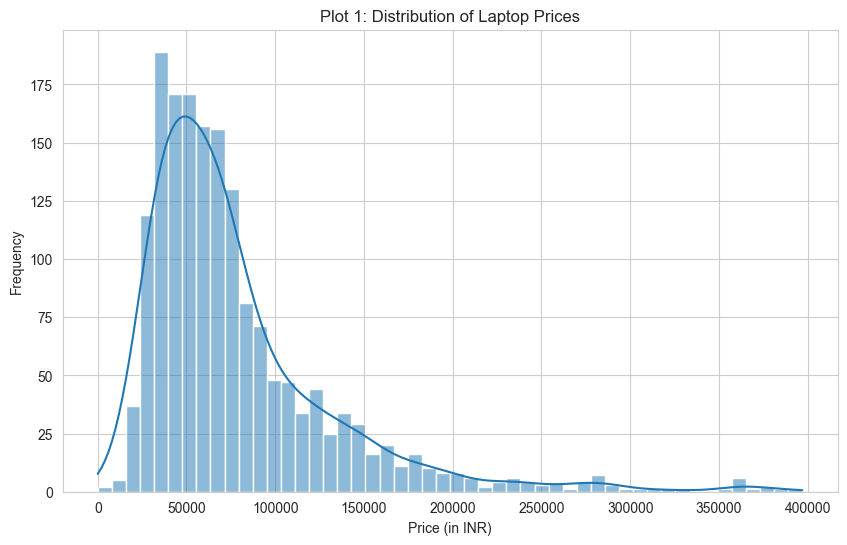

In [48]:
# Plot 1: Analyzing the overall distribution of laptop prices
# A histogram is essential to understand the central tendency, spread, and skewness of the price.
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50)
plt.title('Plot 1: Distribution of Laptop Prices')
plt.xlabel('Price (in INR)')
plt.ylabel('Frequency')
plt.savefig('reports/figures/plot1_price_distribution.png')
plt.show()

# --- Finding ---
# The plot shows a strong right-skew, which justifies our use of log-transformation during modeling.

# 3. Analyzing Relationships Between Core Numerical Features and Price

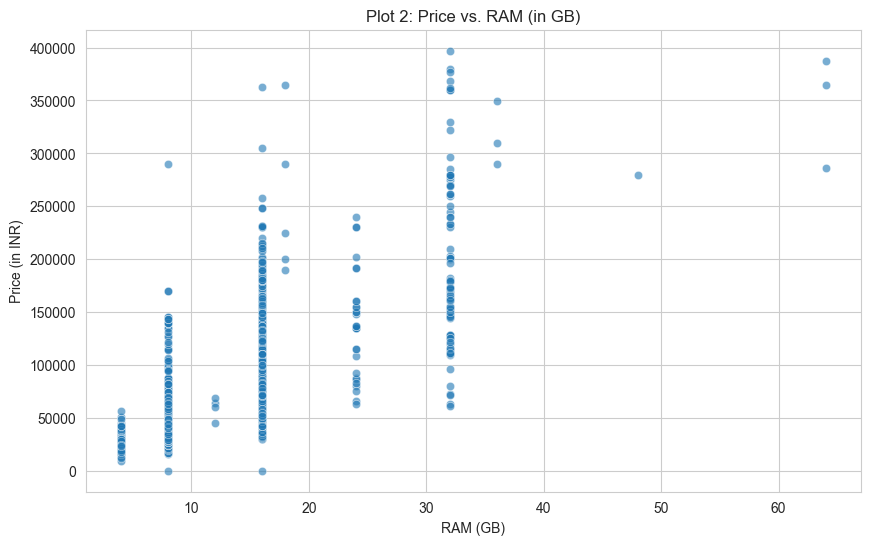

In [49]:
# Plot 2: Creating a scatter plot to investigate the relationship between RAM and price
# This helps us visually confirm if more RAM leads to a higher price.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ram_gb', y='price', data=df, alpha=0.6)
plt.title('Plot 2: Price vs. RAM (in GB)')
plt.xlabel('RAM (GB)')
plt.ylabel('Price (in INR)')
plt.savefig('reports/figures/plot2_price_vs_ram.png')
plt.show()

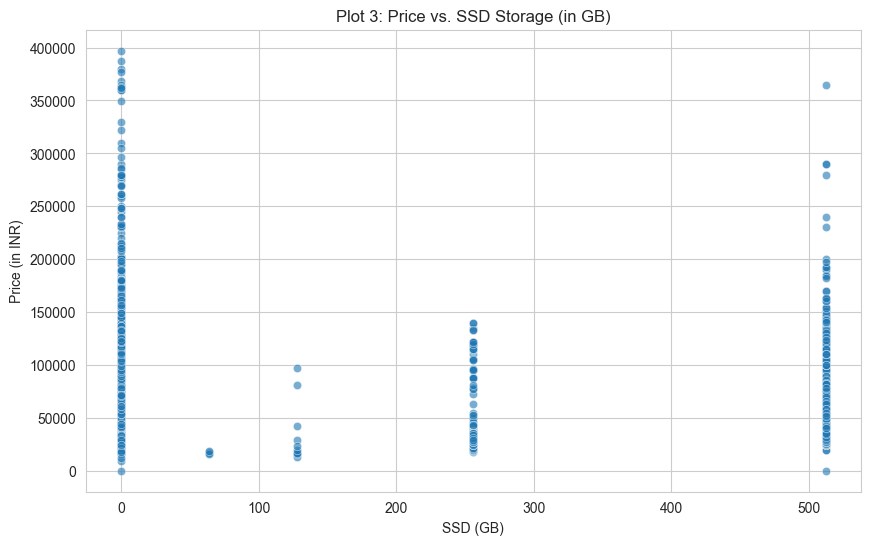

In [50]:
# Plot 3: Creating a scatter plot to investigate the relationship between SSD size and price
# This helps us see the impact of fast storage on the final price.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ssd_gb', y='price', data=df, alpha=0.6)
plt.title('Plot 3: Price vs. SSD Storage (in GB)')
plt.xlabel('SSD (GB)')
plt.ylabel('Price (in INR)')
plt.savefig('reports/figures/plot3_price_vs_ssd.png')
plt.show()

# 4. Analyzing the Impact of Categorical Features

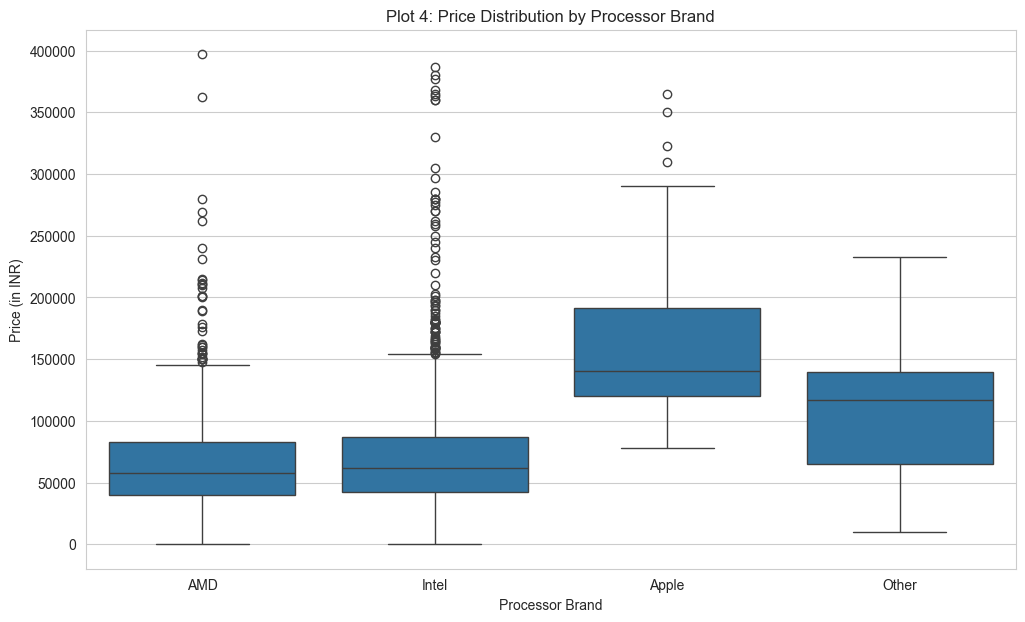

In [51]:
# Plot 4: Using a boxplot to analyze how processor brand affects the price distribution
# This is a key plot to understand brand-based pricing tiers.
plt.figure(figsize=(12, 7))
sns.boxplot(x='processor_brand', y='price', data=df)
plt.title('Plot 4: Price Distribution by Processor Brand')
plt.xlabel('Processor Brand')
plt.ylabel('Price (in INR)')
plt.savefig('reports/figures/plot4_price_by_brand.png')
plt.show()

# --- Finding ---
# This plot clearly shows that laptops with 'Apple' processors are in a distinct, higher price category.

# 5. Overall Feature Correlation Analysis

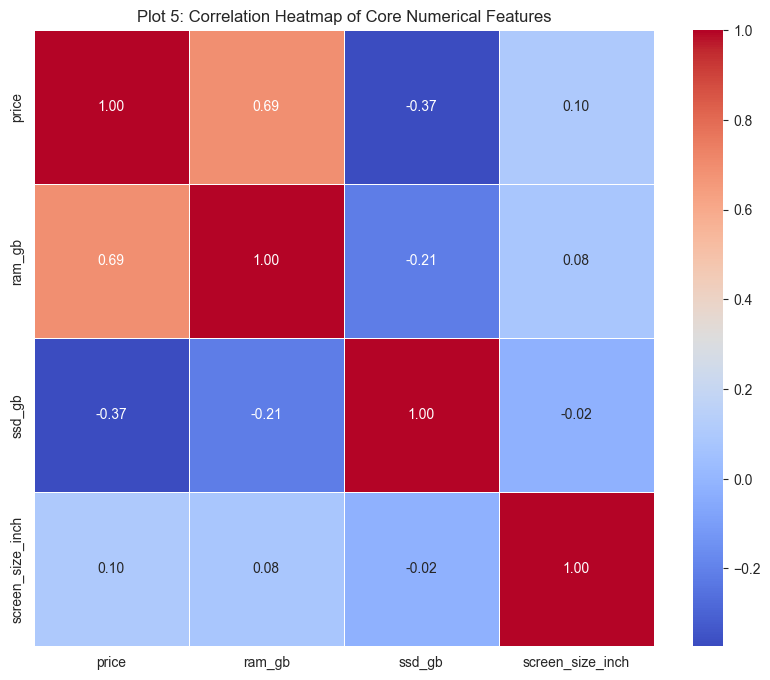

In [52]:
# Plot 5: Generating a correlation heatmap to quantify relationships between all numerical features
# This provides a comprehensive overview of how different specs relate to each other and to the price.
plt.figure(figsize=(10, 8))
# We select only the columns with numbers to create the correlation matrix
numeric_columns = df.select_dtypes(include=np.number)
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Plot 5: Correlation Heatmap of Core Numerical Features')
plt.savefig('reports/figures/plot5_correlation_heatmap.png')
plt.show()

# --- Finding ---
# The heatmap confirms that 'ram_gb' and 'ssd_gb' have the highest positive correlation with 'price'.